<a href="https://colab.research.google.com/github/janzika/CarbonAirTime/blob/main/DataforZikaandChurchCarbonAirtime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook can be used to reproduce processing of data used in Zika and Church (2026). For questions please contact

**Jan D Zika, University of New South Wales, Sydney** j.zika@unsw.edu.au


In [31]:
## install packages and import libraries
!pip install xarray
!pip install cftime
import xarray as xr
import cftime as ctm
import pandas as pd
import scipy as sp
# Numerics
import numpy as np
# Plotting
import matplotlib.pyplot as plt
from google.colab import files
plt.rcParams['figure.figsize'] = [8,8]
# plot figures in Colaboratory notebook
%matplotlib inline

In [32]:
#%%bash
# Mounting requires a special 'bash' command
!git clone https://github.com/janzika/CarbonAirTime.git

fatal: destination path 'CarbonAirTime' already exists and is not an empty directory.


Load emissions data from Meinshausen et al. (2020).

In [33]:
em=pd.read_csv('./CarbonAirTime/SSP_CMIP6_201811/SSP_CMIP6_201811.csv')
em_data_yrs = np.array([2015,2020,2030,2040,2050,2060,2070,2080,2090,2100,2150])
em_years = np.arange(2015,2151)
zeroyr = 2250
reduct = (zeroyr - em_years[-1])/(zeroyr - em_data_yrs[-2])
emCO2_119_raw = np.array(em[(em['VARIABLE'].isin(['CMIP6 Emissions|CO2']) & em['REGION'].isin(['World']) & em['SCENARIO'].isin(['SSP1-19']))].values[0,5:],dtype='float64')
emCO2_126_raw = np.array(em[(em['VARIABLE'].isin(['CMIP6 Emissions|CO2']) & em['REGION'].isin(['World']) & em['SCENARIO'].isin(['SSP1-26']))].values[0,5:],dtype='float64')
emCO2_245_raw = np.array(em[(em['VARIABLE'].isin(['CMIP6 Emissions|CO2']) & em['REGION'].isin(['World']) & em['SCENARIO'].isin(['SSP2-45']))].values[0,5:],dtype='float64')
emCO2_370_raw = np.array(em[(em['VARIABLE'].isin(['CMIP6 Emissions|CO2']) & em['REGION'].isin(['World']) & em['SCENARIO'].isin(['SSP3-70 (Baseline)']))].values[0,5:],dtype='float64')
emCO2_585_raw = np.array(em[(em['VARIABLE'].isin(['CMIP6 Emissions|CO2']) & em['REGION'].isin(['World']) & em['SCENARIO'].isin(['SSP5-85 (Baseline)']))].values[0,5:],dtype='float64')
emCO2_119 = np.interp(em_years,em_data_yrs,np.concat((emCO2_119_raw,[emCO2_119_raw[-1]])))#119 and 126 flat 2100-2150
emCO2_126 = np.interp(em_years,em_data_yrs,np.concat((emCO2_126_raw,[emCO2_126_raw[-1]])))#119 and 126 flat 2100-2150
emCO2_245 = np.interp(em_years,em_data_yrs,np.concat((emCO2_245_raw,[reduct*emCO2_245_raw[-1]])))
emCO2_370 = np.interp(em_years,em_data_yrs,np.concat((emCO2_370_raw,[reduct*emCO2_370_raw[-1]])))
emCO2_585 = np.interp(em_years,em_data_yrs,np.concat((emCO2_585_raw,[reduct*emCO2_585_raw[-1]])))



Load glacier data from Malles and Marzeion (2020), 10.5194/tc-2020-320.

In [34]:
# Load Glacier Data
Glaciers = xr.open_mfdataset('./CarbonAirTime/suppl_reconstruction_data_region.nc')
REGS = ['Alaska','Western Canada and USA','Arctic Canada (North)',\
        'Arctic Canada (South)','Greenland periphery','Iceland',\
        'Svalbard and Jan Mayen','Scandinavia','Russian Arctic','North Asia',\
        'Central Europe','Caucasus and Middle East','Central Asia',\
        'South Asia (West)','South Asia (East)','Low Latitudes',\
        'Southern Andes','New Zealand']

Load emissions data from [Friedlingstein et al](https://doi.org/10.5194/essd-14-4811-2022).

In [35]:
histemall=pd.read_csv('./CarbonAirTime/owid-co2-data.csv')
#histemall=pd.read_csv('https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv')
#display(histemall)
histemwld = histemall[histemall['country'].isin(['World'])]
#histemwld.plot(x='year',y='co2',ylabel='Emissions (Mt / year)')
#histemwld.plot(x='year',y='cumulative_co2',ylabel='Cumulative Emissions (Mt)')


Load GMSL data from [Wang et al 2021](https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2021GL094502).


In [36]:
yr1 = 1950
yr2 = 2014
recon = 'Wang et al., 2024'
#recon = 'Jevrejeva et al., 2014'
#recon = 'Frederikse et al., 2020'

histairtime = np.cumsum(histemwld[histemwld['year']>yr1]['cumulative_co2'])
histairyr = histemwld[histemwld['year']>yr1]['year']
#plt.plot(histairyr,histairtime/1e6)
#plt.ylabel('Carbon Airtime (Tt yr)')
#plt.xlabel('Year')

Load GMSL data from [Wang et al 2021](https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2021GL094502).

In [37]:
# prompt: remove header from CSV file and set second row as variable labels

# Read the CSV file
wangSLR = pd.read_csv('./CarbonAirTime/GMSL_reconstructions_1985-2004baseline.csv', header=None)

# Set the second row as variable labels
wangSLR.columns = wangSLR.iloc[1]

# Drop the first two rows
wangSLR = wangSLR.iloc[2:]
wangSLR = wangSLR.rename(columns={'New reconstruction':'Wang et al., 2024'})

wangSLR = wangSLR.apply(pd.to_numeric)

Load land water storage data from Caceres doi:10.5194/hess-24-4831-2020

In [38]:
caceresSLR = pd.read_csv('./CarbonAirTime/Caceres2020_originaldata_modifiedformat.csv', header=None)
caceresSLR.columns = caceresSLR.iloc[1]
caceresSLR = caceresSLR.iloc[2:]
caceresSLR = caceresSLR.apply(pd.to_numeric)
continent_area_km2 = 132.3e6
ocean_area_km2 = 361e6
Land2Sea_factor = continent_area_km2/ocean_area_km2


Load Altimeter data (https://doi.org/10.5067/GMSLM-TJ152)

In [39]:
#Altimeter Data GMSL_TPJAOS_5.2.csv

# Read the CSV file
altiSLR = pd.read_csv('./CarbonAirTime/NASA_SSH_GMSL_INDICATOR_20250508.csv')
altiSLR['year']=altiSLR['Year'].round()
altiSLR_annual = 10*altiSLR.groupby("year")["GMSL with 60-day smoothing applied (cm)"].mean()


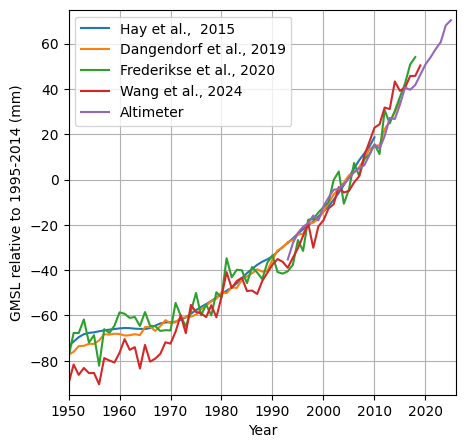

In [40]:
plt.rcParams['figure.figsize'] = [5, 5]
# prompt: plot all columns in wangSLR vs the Year column
wangsubset = ['Hay et al.,  2015','Dangendorf et al., 2019',\
              'Frederikse et al., 2020','Wang et al., 2024']
#for column in wangSLR.columns[1:]:
for column in wangsubset:
  if column=='Hay et al.,  2015':
    plt.plot(wangSLR['Year'], wangSLR[column]-wangSLR[column][(wangSLR.Year>1998) & (wangSLR.Year<2011)].mean(), label=column)
  else:
    plt.plot(wangSLR['Year'], wangSLR[column]-wangSLR[column][(wangSLR.Year>1994) & (wangSLR.Year<2015)].mean(), label=column)

plt.plot(altiSLR_annual.index,(altiSLR_annual-\
         altiSLR_annual[(altiSLR_annual.index>1994) & (altiSLR_annual.index<2015)].mean()),
         label='Altimeter')

plt.ylabel('GMSL relative to 1995-2014 (mm)')
plt.xlabel('Year')
plt.xlim([1950,2026])
plt.ylim([-95,75])
plt.grid()
plt.legend()
plt.show()


Load data for non-CO2 driven warming (and cooling) derived using the FaIR model (https://doi.org/10.5194/gmd-17-8569-2024)

In [41]:
fair_Temp_noCO2 = pd.read_csv('./CarbonAirTime/FAIR_NON_CO2_GHGs_SIMULATION_17501850_offset.csv')


Create data set

In [42]:
# Create data frame from 1750 to 2150
yrs = np.arange(1750,2500)
data = {
    "Year":yrs,
    "Hay et al.,  2015 (mm)":yrs+np.nan,
    "Dangendorf et al., 2019 (mm)":yrs+np.nan,
    "Frederikse et al., 2020 (mm)":yrs+np.nan,
    "Wang et al., 2024 (mm)":yrs+np.nan,
    "Altimeter (mm)":yrs+np.nan,
    "Historical glacier (mm)":yrs+np.nan,
    "Historical ocean (1e22 j)":yrs+np.nan,
    "Historical land water (mm)":yrs+np.nan,
    "Historical cumilative CO_2 emissions (TtC)":yrs+np.nan,
    "Historical non-CO_2 forcing (TtC; CO_2 equiv.)":yrs+np.nan,
    "SSP119 cumilative CO_2 emissions (TtC)":yrs+np.nan,
    "SSP126 cumilative CO_2 emissions (TtC)":yrs+np.nan,
    "SSP245 cumilative CO_2 emissions (TtC)":yrs+np.nan,
    "SSP370 cumilative CO_2 emissions (TtC)":yrs+np.nan,
    "SSP585 cumilative CO_2 emissions (TtC)":yrs+np.nan,
    "SSP119 non-CO_2 forcing (TtC; CO_2 equiv.)":yrs+np.nan,
    "SSP126 non-CO_2 forcing (TtC; CO_2 equiv.)":yrs+np.nan,
    "SSP245 non-CO_2 forcing (TtC; CO_2 equiv.)":yrs+np.nan,
    "SSP370 non-CO_2 forcing (TtC; CO_2 equiv.)":yrs+np.nan,
    "SSP585 non-CO_2 forcing (TtC; CO_2 equiv.)":yrs+np.nan,
    "Projected GMSL SSP119 (mm)":yrs+np.nan,
    "Projected GMSL SSP126 (mm)":yrs+np.nan,
    "Projected GMSL SSP245 (mm)":yrs+np.nan,
    "Projected GMSL SSP370 (mm)":yrs+np.nan,
    "Projected GMSL SSP585 (mm)":yrs+np.nan,
    "Projected GMSL SSP119 Median (mm)":yrs+np.nan,
    "Projected GMSL SSP126 Median (mm)":yrs+np.nan,
    "Projected GMSL SSP245 Median (mm)":yrs+np.nan,
    "Projected GMSL SSP370 Median (mm)":yrs+np.nan,
    "Projected GMSL SSP585 Median (mm)":yrs+np.nan,
    "Projected GMSL SSP119 Upper (mm)":yrs+np.nan,
    "Projected GMSL SSP126 Upper (mm)":yrs+np.nan,
    "Projected GMSL SSP245 Upper (mm)":yrs+np.nan,
    "Projected GMSL SSP370 Upper (mm)":yrs+np.nan,
    "Projected GMSL SSP585 Upper (mm)":yrs+np.nan,
    "Projected GMSL SSP119 Lower (mm)":yrs+np.nan,
    "Projected GMSL SSP126 Lower (mm)":yrs+np.nan,
    "Projected GMSL SSP245 Lower (mm)":yrs+np.nan,
    "Projected GMSL SSP370 Lower (mm)":yrs+np.nan,
    "Projected GMSL SSP585 Lower (mm)":yrs+np.nan,
    "Projected glacier SSP119 (mm)":yrs+np.nan,
    "Projected glacier SSP126 (mm)":yrs+np.nan,
    "Projected glacier SSP245 (mm)":yrs+np.nan,
    "Projected glacier SSP370 (mm)":yrs+np.nan,
    "Projected glacier SSP585 (mm)":yrs+np.nan,
    "Projected ocean heat SSP119 (mm)":yrs+np.nan,
    "Projected ocean heat SSP126 (mm)":yrs+np.nan,
    "Projected ocean heat SSP245 (mm)":yrs+np.nan,
    "Projected ocean heat SSP370 (mm)":yrs+np.nan,
    "Projected ocean heat SSP585 (mm)":yrs+np.nan,
}
df = pd.DataFrame(data)

Load AR6 SL contribution projections (https://podaac.jpl.nasa.gov/announcements/2021-08-09-Sea-level-projections-from-the-IPCC-6th-Assessment-Report).

In [43]:
#df.insert(0,"Historical Carbon Airtime (C0_2)",np.cumsum(histemwld.co2[histemwld.year<2015]).values/1e6)
massCmassCO2 = 12.01/44.01; #(molar mass of CO2)/(molar mass of C)
Mt2GMSL = 1000*1e12/(1032*361e12)#(m in a millimetre)*(kg in a megatonne)/((Density of water)*(area of ocean))
CCR = 1.65 #IPCC AR6

df.loc[(df.Year>wangSLR.iloc[0]['Year']-1) & (df.Year<wangSLR.iloc[-1]['Year']+1),\
       'Hay et al.,  2015 (mm)']=wangSLR['Hay et al.,  2015'].values-\
       wangSLR['Hay et al.,  2015'][(wangSLR.Year>1998) & (wangSLR.Year<2011)].mean()
#Hay only runs to 2010 so subtract 1999-2010 mean so centred on same year
df.loc[(df.Year>wangSLR.iloc[0]['Year']-1) & (df.Year<wangSLR.iloc[-1]['Year']+1),\
       'Dangendorf et al., 2019 (mm)']=\
       wangSLR['Dangendorf et al., 2019'].values-\
       wangSLR['Dangendorf et al., 2019'][(wangSLR.Year>1994) & (wangSLR.Year<2015)].mean()
df.loc[(df.Year>wangSLR.iloc[0]['Year']-1) & (df.Year<wangSLR.iloc[-1]['Year']+1),\
       'Frederikse et al., 2020 (mm)']=\
       wangSLR['Frederikse et al., 2020'].values-\
       wangSLR['Frederikse et al., 2020'][(wangSLR.Year>1994) & (wangSLR.Year<2015)].mean()
df.loc[(df.Year>wangSLR.iloc[0]['Year']-1) & (df.Year<wangSLR.iloc[-1]['Year']+1),\
       'Wang et al., 2024 (mm)']=wangSLR['Wang et al., 2024'].values-\
       wangSLR['Wang et al., 2024'][(wangSLR.Year>1994) & (wangSLR.Year<2015)].mean()

df.loc[(df.Year>altiSLR_annual.index[0]-1) & (df.Year<altiSLR_annual.index[-1]+1-1),\
       'Altimeter (mm)'] = altiSLR_annual.values[0:-1]-\
altiSLR_annual[(altiSLR_annual.index>1994) & (altiSLR_annual.index<2015)].mean()
'''
df.loc[(df.Year<(Glaciers['Time'][-1].values+1900+1)) & \
 (df.Year>(Glaciers['Time'][0].values+1900-1)),'Historical glacier (mm)'] = \
 - Mt2GMSL*np.sum(Glaciers['Mass'][9,:,:],axis=1).values

df.loc[(df.Year>ANNUAL_OHC_0_6km.index[0]-1) & \
  (df.Year<ANNUAL_OHC_0_6km.index[-1]+1),'Historical ocean (1e22 j)'] = \
  ANNUAL_OHC_0_6km.values
'''
# Minus so how much flows into ocean
df.loc[(df.Year>caceresSLR.iloc[0]['year']-1) & \
 (df.Year<caceresSLR.iloc[-1]['year']+1),'Historical land water (mm)'] = \
- (caceresSLR['human-driven lwsa (ensemble mean)'].values - \
   caceresSLR['human-driven lwsa (ensemble mean)']\
    [(caceresSLR.year>1994) & (caceresSLR.year>1994)].mean())*Land2Sea_factor

#Convert to mass of C
df.loc[df.Year<2024,'Historical cumilative CO_2 emissions (TtC)']= massCmassCO2*\
  np.cumsum(histemwld.co2)[histemwld.year<2024].values/1e6

df.loc[df.Year<2024,'Historical non-CO_2 forcing (TtC; CO_2 equiv.)']= \
  fair_Temp_noCO2['temp_ssp126'][fair_Temp_noCO2['Year']<2024]/CCR

df.loc[(df.Year>2014) & (df.Year<2151),'SSP119 cumilative CO_2 emissions (TtC)']=\
  massCmassCO2*(np.cumsum(emCO2_119))/1e6 + \
  df.loc[df.Year==2014,'Historical cumilative CO_2 emissions (TtC)'].values
df.loc[(df.Year>2014) & (df.Year<2151),'SSP126 cumilative CO_2 emissions (TtC)']=\
  massCmassCO2*(np.cumsum(emCO2_126))/1e6 + \
  df.loc[df.Year==2014,'Historical cumilative CO_2 emissions (TtC)'].values
df.loc[(df.Year>2014) & (df.Year<2151),'SSP245 cumilative CO_2 emissions (TtC)']=\
  massCmassCO2*(np.cumsum(emCO2_245))/1e6 + \
  df.loc[df.Year==2014,'Historical cumilative CO_2 emissions (TtC)'].values
df.loc[(df.Year>2014) & (df.Year<2151),'SSP370 cumilative CO_2 emissions (TtC)']=\
  massCmassCO2*(np.cumsum(emCO2_370))/1e6 + \
  df.loc[df.Year==2014,'Historical cumilative CO_2 emissions (TtC)'].values
df.loc[(df.Year>2014) & (df.Year<2151),'SSP585 cumilative CO_2 emissions (TtC)']=\
  massCmassCO2*(np.cumsum(emCO2_585))/1e6 + \
  df.loc[df.Year==2014,'Historical cumilative CO_2 emissions (TtC)'].values

yrEx1=2100
yrEx1p1=2140
yrEx1p2=2190
yrEx2=2250
yrEx3=2500
YRSpst2100 = np.arange(0,yrEx3-yrEx1-1,1)
# For scenarios with negative emissions in 2100
EMExfactor_neg = np.concatenate((\
              ((1+0*(YRSpst2100[YRSpst2100<(yrEx1p1-yrEx1)]))),\
              ((1-((YRSpst2100[(YRSpst2100>=(yrEx1p1-yrEx1)) & \
               (YRSpst2100<(yrEx1p2-yrEx1))]-(yrEx1p1-yrEx1))\
             /(yrEx1p2-yrEx1p1)))),\
              (0*YRSpst2100[YRSpst2100>=(yrEx1p2-yrEx1)])))

df.loc[(df.Year>2100),'SSP119 cumilative CO_2 emissions (TtC)']=\
  massCmassCO2*(np.cumsum(emCO2_119[-50]*EMExfactor_neg))/1e6 + \
  df.loc[df.Year==2100,'SSP119 cumilative CO_2 emissions (TtC)'].values
df.loc[(df.Year>2100),'SSP126 cumilative CO_2 emissions (TtC)']=\
  massCmassCO2*(np.cumsum(emCO2_126[-50]*EMExfactor_neg))/1e6 + \
  df.loc[df.Year==2100,'SSP126 cumilative CO_2 emissions (TtC)'].values

# For scenarios with positive emissions in 2100
EMExfactor_pos = np.concatenate((((1-(YRSpst2100[YRSpst2100<(yrEx2-yrEx1)]\
             /(yrEx2-yrEx1)))), (0*YRSpst2100[YRSpst2100>=(yrEx2-yrEx1)])))

df.loc[(df.Year>2100),'SSP245 cumilative CO_2 emissions (TtC)']=\
  massCmassCO2*(np.cumsum(emCO2_245[-50]*EMExfactor_pos))/1e6 + \
  df.loc[df.Year==2100,'SSP245 cumilative CO_2 emissions (TtC)'].values
df.loc[(df.Year>2100),'SSP370 cumilative CO_2 emissions (TtC)']=\
  massCmassCO2*(np.cumsum(emCO2_370[-50]*EMExfactor_pos))/1e6 + \
  df.loc[df.Year==2100,'SSP370 cumilative CO_2 emissions (TtC)'].values
df.loc[(df.Year>2100),'SSP585 cumilative CO_2 emissions (TtC)']=\
  massCmassCO2*(np.cumsum(emCO2_585[-50]*EMExfactor_pos))/1e6 + \
  df.loc[df.Year==2100,'SSP585 cumilative CO_2 emissions (TtC)'].values

df.loc[df.Year>2014,'SSP119 non-CO_2 forcing (TtC; CO_2 equiv.)']= \
  fair_Temp_noCO2['temp_ssp119'][fair_Temp_noCO2['Year']>2014]/CCR
df.loc[df.Year>2014,'SSP126 non-CO_2 forcing (TtC; CO_2 equiv.)']= \
  fair_Temp_noCO2['temp_ssp126'][fair_Temp_noCO2['Year']>2014]/CCR
df.loc[df.Year>2014,'SSP245 non-CO_2 forcing (TtC; CO_2 equiv.)']= \
  fair_Temp_noCO2['temp_ssp245'][fair_Temp_noCO2['Year']>2014]/CCR
df.loc[df.Year>2014,'SSP370 non-CO_2 forcing (TtC; CO_2 equiv.)']= \
  fair_Temp_noCO2['temp_ssp370'][fair_Temp_noCO2['Year']>2014]/CCR
df.loc[df.Year>2014,'SSP585 non-CO_2 forcing (TtC; CO_2 equiv.)']= \
  fair_Temp_noCO2['temp_ssp585'][fair_Temp_noCO2['Year']>2014]/CCR


In [44]:
SCENS = ['119','126','245','370','585']
COMPS = ['GMSL','ocean heat','glacier']
COMFIL = ['total']#,'oceandynamics','glaciers']
ref_year = 2005
proj_years = np.arange(2015,2151)
for scen in SCENS:
 for i in range(0,len(COMFIL)):
  IPCC = xr.open_mfdataset(\
    './CarbonAirTime/confidence_output_files/medium_confidence/ssp'+scen+\
                    '/'+COMFIL[i]+'_ssp'+scen+'_medium_confidence_values.nc')
  ipccrawyears = np.concatenate(([ref_year],\
    IPCC.years[IPCC['years']<=2150].values))
  ipccraw_mean = np.concatenate(([0],\
    np.mean(IPCC.sea_level_change[:,\
                          IPCC['years']<=2150,0].values,axis=0)))
  ipccraw_median = np.concatenate(([0],\
    IPCC.sea_level_change[IPCC['quantiles']==0.5,\
                          IPCC['years']<=2150,0].values[0,]))
  ipccraw_u = np.concatenate(([0],\
    IPCC.sea_level_change[IPCC['quantiles']==0.87,\
                          IPCC['years']<=2150,0].values[0,]))
  ipccraw_l = np.concatenate(([0],\
    IPCC.sea_level_change[IPCC['quantiles']==0.13,\
                          IPCC['years']<=2150,0].values[0,]))

  df.loc[(df.Year>2014) & (df.Year<2151),'Projected ' + COMPS[i]+ ' SSP'+scen+' (mm)']=\
    np.interp(proj_years,ipccrawyears,ipccraw_mean)
  df.loc[(df.Year>2014) & (df.Year<2151),'Projected ' + COMPS[i]+ ' SSP'+scen+' Median (mm)']=\
    np.interp(proj_years,ipccrawyears,ipccraw_median)
  df.loc[(df.Year>2014) & (df.Year<2151),'Projected ' + COMPS[i]+ ' SSP'+scen+' Upper (mm)']=\
    np.interp(proj_years,ipccrawyears,ipccraw_u)
  df.loc[(df.Year>2014) & (df.Year<2151),'Projected ' + COMPS[i]+ ' SSP'+scen+' Lower (mm)']=\
    np.interp(proj_years,ipccrawyears,ipccraw_l)

Save file.

In [45]:
'''
from google.colab import drive
drive.mount('/content/drive')
df.to_csv('AirTimeAllData_v15.csv')
!cp AirTimeAllData_v15.csv "/content/drive/My Drive/"
!fusermount -u /content/drive
'''

'\nfrom google.colab import drive\ndrive.mount(\'/content/drive\')\ndf.to_csv(\'AirTimeAllData_v15.csv\')\n!cp AirTimeAllData_v15.csv "/content/drive/My Drive/"\n!fusermount -u /content/drive\n'